/Users/littlebrown/opt/anaconda3/envs/dsc80/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/littlebrown/opt/anaconda3/envs/dsc80/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/littlebrown/opt/anaconda3/envs/dsc80/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/littlebrown/opt/anaconda3/envs/dsc80/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal app

STATISTICAL ANALYSIS REPORT

Q1: GAUSSIAN NOISE
------------------------------------------------------------------------
Summary:
 noise_sigma  n     mean      std  ci_lower  ci_upper
        0.00 25 0.056294 0.111701  0.010187  0.102402
        0.01 25 0.053839 0.107247  0.009570  0.098109
        0.03 25 0.029079 0.053089  0.007164  0.050993
        0.05 25 0.042854 0.060486  0.017886  0.067821
        0.10 25 0.117541 0.082565  0.083460  0.151622

Paired Wilcoxon tests (alternative: condition > baseline):
             comparison  noise_sigma  n  median_diff_mm  statistic  p_value  p_adjusted  significant
sigma_0.01 vs sigma_0.0         0.01 25        0.000000        6.0 0.953554    1.000000        False
sigma_0.03 vs sigma_0.0         0.03 25        0.000000       28.0 0.805907    1.000000        False
sigma_0.05 vs sigma_0.0         0.05 25        0.000000       86.0 0.326459    0.979377        False
 sigma_0.1 vs sigma_0.0         0.10 25        0.091746      208.0 0.004073    0.0

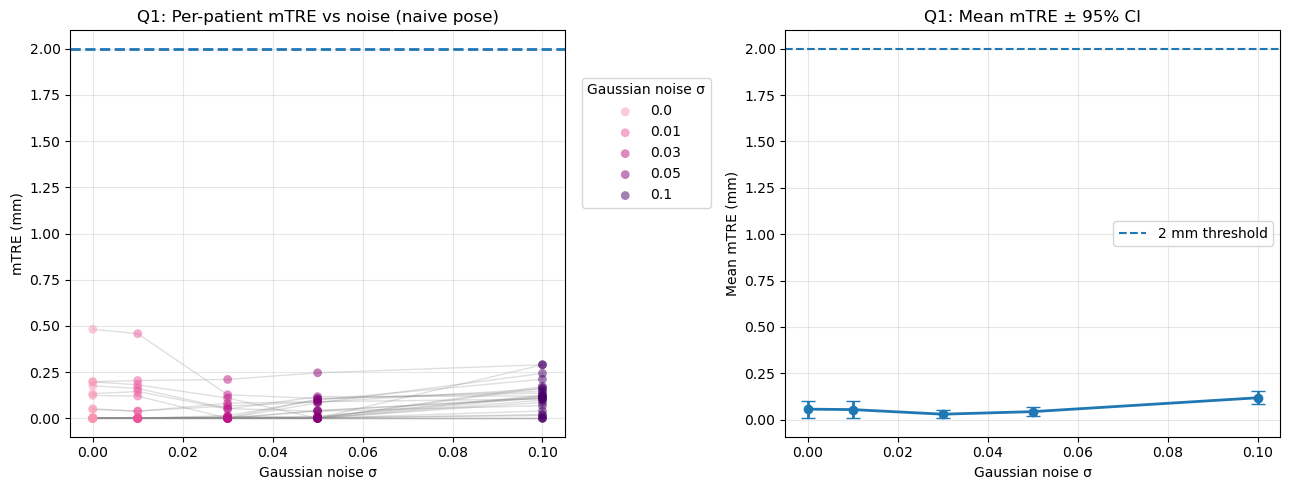

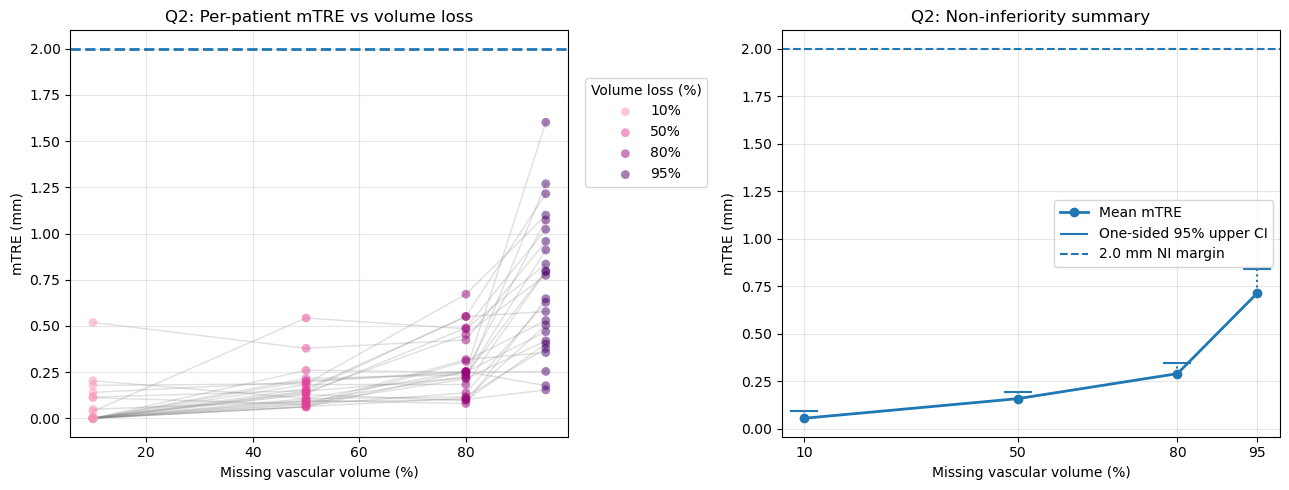

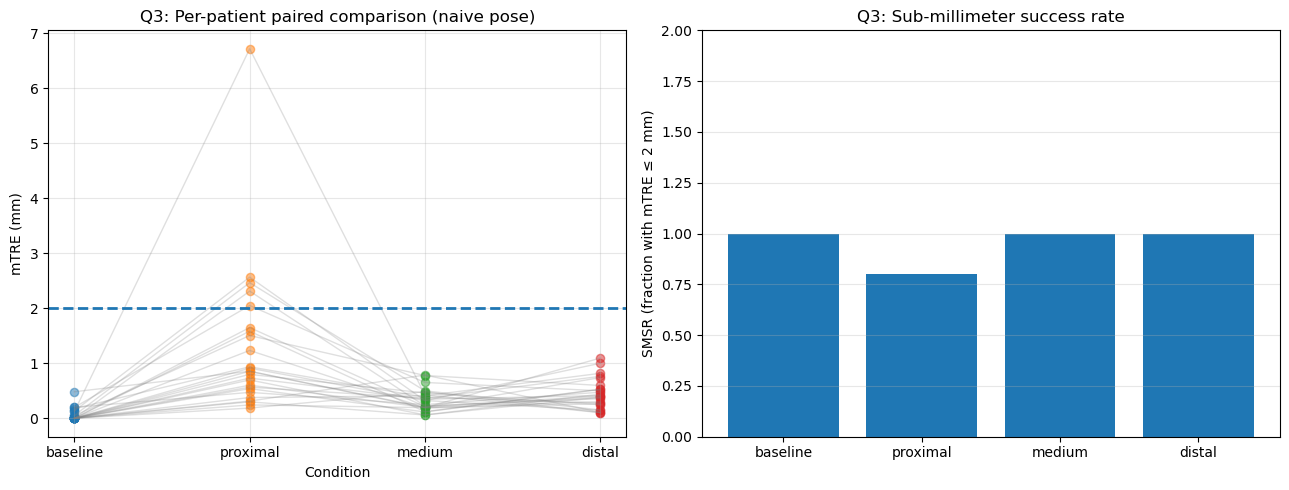

In [ ]:
# statistical_analysis_and_visualization.py

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, friedmanchisquare, t
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Load and standardize data
# ============================================================

def load_results_from_folder(folder="data"):
    """
    Load all per-patient registration result CSVs from a folder.

    Default folder: ./data
    Expected files:
        data/001_diffpose_registration_results.csv
        data/002_diffpose_registration_results.csv
        data/003_diffpose_registration_results.csv
    """

    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(f"Data folder not found: {folder}")

    csv_files = sorted(folder.glob("*_diffpose_registration_results.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No result CSV files found in {folder}")

    dfs = []
    for fp in csv_files:
        df = pd.read_csv(fp)

        # extract patient id from filename
        patient_id = fp.name.split("_")[0]
        df["patient_id"] = patient_id

        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # normalize experiment names
    exp_map = {
        "Q1_gaussian": "Q1",
        "Q2_volume_loss": "Q2",
        "Q3_group_removal": "Q3",
    }
    df["question"] = df["experiment"].map(exp_map)

    # prepare parsed columns
    df["noise_sigma"] = np.nan
    df["volume_loss_frac"] = np.nan
    df["vessel_group"] = np.nan

    # Q1 parsing
    q1_mask = df["question"] == "Q1"
    df.loc[q1_mask, "noise_sigma"] = (
        df.loc[q1_mask, "case"]
        .str.extract(r"sigma_([0-9.]+)", expand=False)
        .astype(float)
    )

    # Q2 parsing
    q2_mask = df["question"] == "Q2"
    q2_loss_str = df.loc[q2_mask, "case"].str.extract(r"loss_(\d+)", expand=False)
    df.loc[q2_mask, "volume_loss_frac"] = q2_loss_str.astype(float) / 100.0

    # Q3 parsing
    q3_mask = df["question"] == "Q3"
    df.loc[q3_mask, "vessel_group"] = df.loc[q3_mask, "case"]

    return df


# ============================================================
# 2. Helper functions
# ============================================================

def mean_ci(series, alpha=0.05):
    """
    Two-sided t-based confidence interval for the mean.
    """
    x = pd.Series(series).dropna().astype(float)
    n = len(x)
    mean = x.mean()

    if n < 2:
        return {
            "n": n,
            "mean": mean,
            "std": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
        }

    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = t.ppf(1 - alpha / 2, df=n - 1)

    return {
        "n": n,
        "mean": mean,
        "std": sd,
        "ci_lower": mean - tcrit * se,
        "ci_upper": mean + tcrit * se,
    }


def upper_one_sided_ci_mean(series, alpha=0.05):
    """
    One-sided upper confidence bound for the mean using t-distribution.

    Used for Q2 non-inferiority:
        If upper bound < margin, conclude non-inferior.
    """
    x = pd.Series(series).dropna().astype(float)
    n = len(x)
    mean = x.mean()

    if n < 2:
        return {
            "n": n,
            "mean": mean,
            "std": np.nan,
            "upper_ci": np.nan,
        }

    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = t.ppf(1 - alpha, df=n - 1)  # one-sided upper
    upper = mean + tcrit * se

    return {
        "n": n,
        "mean": mean,
        "std": sd,
        "upper_ci": upper,
    }


def paired_wilcoxon_by_patient(df, baseline_selector, condition_selector, value_col="mTRE_mm",
                               alternative="greater"):
    """
    Build a paired patient-level dataset and run Wilcoxon signed-rank test.

    alternative='greater' tests whether:
        condition - baseline > 0
    i.e., condition worsens mTRE.
    """
    base = df[baseline_selector].copy()[["patient_id", value_col]]
    cond = df[condition_selector].copy()[["patient_id", value_col]]

    base = base.rename(columns={value_col: "baseline"})
    cond = cond.rename(columns={value_col: "condition"})

    paired = pd.merge(base, cond, on="patient_id", how="inner")
    paired["diff"] = paired["condition"] - paired["baseline"]

    if len(paired) == 0:
        return {
            "n": 0,
            "paired": paired,
            "statistic": np.nan,
            "p_value": np.nan,
            "median_diff": np.nan,
        }

    # If all differences are zero, scipy may fail; handle that cleanly
    if np.allclose(paired["diff"].values, 0):
        return {
            "n": len(paired),
            "paired": paired,
            "statistic": 0.0,
            "p_value": 1.0,
            "median_diff": 0.0,
        }

    stat, p = wilcoxon(
        paired["condition"],
        paired["baseline"],
        alternative=alternative,
        zero_method="wilcox",
        correction=False,
        mode="auto",
    )

    return {
        "n": len(paired),
        "paired": paired,
        "statistic": stat,
        "p_value": p,
        "median_diff": paired["diff"].median(),
    }


# ============================================================
# 3. Q1 Analysis
# ============================================================

def analyze_q1(df):
    """
    Q1:
    Paired tests comparing sigma=0.0 baseline vs each non-zero noise level.

    H0: median(condition - baseline) = 0
    H1: median(condition - baseline) > 0
        (noise worsens registration)
    """
    q1 = df[df["question"] == "Q1"].copy()

    summary_rows = []
    for sigma, sub in q1.groupby("noise_sigma"):
        stats = mean_ci(sub["mTRE_mm"])
        summary_rows.append({
            "noise_sigma": sigma,
            **stats
        })
    summary_df = pd.DataFrame(summary_rows).sort_values("noise_sigma")

    baseline_sigma = 0.0
    comparisons = []

    for sigma in sorted(q1["noise_sigma"].dropna().unique()):
        if sigma == baseline_sigma:
            continue

        result = paired_wilcoxon_by_patient(
            q1,
            baseline_selector=(q1["noise_sigma"] == baseline_sigma),
            condition_selector=(q1["noise_sigma"] == sigma),
            value_col="mTRE_mm",
            alternative="greater",
        )

        comparisons.append({
            "comparison": f"sigma_{sigma} vs sigma_{baseline_sigma}",
            "noise_sigma": sigma,
            "n": result["n"],
            "median_diff_mm": result["median_diff"],
            "statistic": result["statistic"],
            "p_value": result["p_value"],
        })

    comp_df = pd.DataFrame(comparisons)
    if len(comp_df) > 0:
        reject, p_adj, _, _ = multipletests(comp_df["p_value"], alpha=0.05, method="holm")
        comp_df["p_adjusted"] = p_adj
        comp_df["significant"] = reject

    return {
        "summary": summary_df,
        "comparisons": comp_df,
    }


# ============================================================
# 4. Q2 Analysis
# ============================================================

def analyze_q2(df, non_inferiority_margin_mm=2.0):
    """
    Q2:
    One-sided non-inferiority analysis for each volume-loss level.

    Baseline is loss_000 (0% volume loss), but the non-inferiority
    decision is evaluated separately at each loss level using:
        one-sided 95% upper CI of mean mTRE.

    Decision rule:
        if upper CI < margin, declare non-inferior.
    """
    q2 = df[df["question"] == "Q2"].copy()

    if q2.empty:
        return {"non_inferiority": pd.DataFrame()}

    # sort levels numerically so 0.95 appears after 0.80
    q2 = q2.sort_values(["volume_loss_frac", "patient_id"])

    rows = []
    for frac in sorted(q2["volume_loss_frac"].dropna().unique()):
        sub = q2[q2["volume_loss_frac"] == frac].copy()
        stats = upper_one_sided_ci_mean(sub["mTRE_mm"], alpha=0.05)

        rows.append({
            "case_label": f"loss_{int(round(frac * 100)):03d}",
            "volume_loss_frac": frac,
            "volume_loss_pct": frac * 100,
            "is_baseline": np.isclose(frac, 0.0),
            "margin_mm": non_inferiority_margin_mm,
            "is_non_inferior": (
                pd.notna(stats["upper_ci"]) and stats["upper_ci"] < non_inferiority_margin_mm
            ),
            **stats,
        })

    summary_df = pd.DataFrame(rows).sort_values("volume_loss_frac").reset_index(drop=True)

    return {
        "non_inferiority": summary_df
    }


# ============================================================
# 5. Q3 Analysis
# ============================================================

def analyze_q3(df):
    """
    Q3:
    (i) Paired Wilcoxon tests: baseline vs proximal/medium/distal
    (ii) Friedman test among proximal, medium, distal
    """
    q3 = df[df["question"] == "Q3"].copy()

    summary_rows = []
    for grp, sub in q3.groupby("vessel_group"):
        stats = mean_ci(sub["mTRE_mm"])
        summary_rows.append({
            "vessel_group": grp,
            "smsr_le1mm": (sub["mTRE_mm"] <= 2.0).mean(),
            **stats
        })
    summary_df = pd.DataFrame(summary_rows)

    # (i) baseline vs each occlusion group
    comparisons = []
    for grp in ["proximal", "medium", "distal"]:
        result = paired_wilcoxon_by_patient(
            q3,
            baseline_selector=(q3["vessel_group"] == "baseline"),
            condition_selector=(q3["vessel_group"] == grp),
            value_col="mTRE_mm",
            alternative="greater",
        )

        comparisons.append({
            "comparison": f"{grp} vs baseline",
            "vessel_group": grp,
            "n": result["n"],
            "median_diff_mm": result["median_diff"],
            "statistic": result["statistic"],
            "p_value": result["p_value"],
        })

    comp_df = pd.DataFrame(comparisons)
    if len(comp_df) > 0:
        reject, p_adj, _, _ = multipletests(comp_df["p_value"], alpha=0.05, method="holm")
        comp_df["p_adjusted"] = p_adj
        comp_df["significant"] = reject

    # (ii) Friedman among occlusion types only
    friedman_result = None
    pivot = q3[q3["vessel_group"].isin(["proximal", "medium", "distal"])].pivot(
        index="patient_id",
        columns="vessel_group",
        values="mTRE_mm"
    )

    if set(["proximal", "medium", "distal"]).issubset(pivot.columns) and len(pivot.dropna()) >= 2:
        pivot = pivot[["proximal", "medium", "distal"]].dropna()
        stat, p = friedmanchisquare(
            pivot["proximal"],
            pivot["medium"],
            pivot["distal"]
        )
        friedman_result = {
            "n": len(pivot),
            "statistic": stat,
            "p_value": p,
            "significant": p < 0.05,
        }

    return {
        "summary": summary_df,
        "baseline_comparisons": comp_df,
        "friedman_test": friedman_result,
    }


# ============================================================
# 6. Reporting
# ============================================================

def generate_report(df, q2_margin_mm=2.0):
    q1 = analyze_q1(df)
    q2 = analyze_q2(df, non_inferiority_margin_mm=q2_margin_mm)
    q3 = analyze_q3(df)

    lines = []
    lines.append("=" * 72)
    lines.append("STATISTICAL ANALYSIS REPORT")
    lines.append("=" * 72)

    # Q1
    lines.append("\nQ1: GAUSSIAN NOISE")
    lines.append("-" * 72)
    lines.append("Summary:")
    lines.append(q1["summary"].to_string(index=False))

    lines.append("\nPaired Wilcoxon tests (alternative: condition > baseline):")
    if len(q1["comparisons"]) > 0:
        lines.append(q1["comparisons"].to_string(index=False))
    else:
        lines.append("No Q1 comparisons available.")

    # Q2
    lines.append("\nQ2: VOLUME LOSS")
    lines.append("-" * 72)
    lines.append(f"Non-inferiority margin = {q2_margin_mm:.2f} mm")
    lines.append(q2["non_inferiority"].to_string(index=False))

    # Q3
    lines.append("\nQ3: VESSEL GROUP OCCLUSION")
    lines.append("-" * 72)
    lines.append("Summary:")
    lines.append(q3["summary"].to_string(index=False))

    lines.append("\nPaired baseline comparisons:")
    lines.append(q3["baseline_comparisons"].to_string(index=False))

    lines.append("\nFriedman test among proximal / medium / distal:")
    if q3["friedman_test"] is None:
        lines.append("Not enough complete paired data to run Friedman test.")
    else:
        lines.append(str(q3["friedman_test"]))

    return "\n".join(lines)


# ============================================================
# 7. Visualizations
# ============================================================

import numpy as np

def paired_plot(ax, df, x_col, y_col, group_col, order, xlabel, ylabel, title, hline=None):
    xpos = np.arange(len(order))
    rng = np.random.default_rng(0)

    # --- 1. thin gray paired lines ---
    for pid, sub in df.groupby(group_col):
        sub = sub.set_index(x_col).reindex(order).reset_index()
        ax.plot(xpos, sub[y_col], color="gray", alpha=0.25, linewidth=1)

    # --- 2. points ---
    for i, cond in enumerate(order):
        y = df[df[x_col] == cond][y_col].values
        x = np.full(len(y), i, dtype=float)  
        ax.scatter(x, y, s=35, alpha=0.5)

#     # --- 3. bold mean line ---
#     means = df.groupby(x_col)[y_col].mean().reindex(order)
#     ax.plot(xpos, means.values, marker="o", linewidth=3)

    # --- formatting ---
    if hline is not None:
        ax.axhline(hline, linestyle="--", linewidth=2)

    ax.set_xticks(xpos)
    ax.set_xticklabels(order)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)

def paired_plot_numeric_x(
    ax,
    df,
    x_col,
    y_col,
    group_col,
    xlabel,
    ylabel,
    title,
    hline=None,
    x_transform=None,
    cmap="RdPu",#"viridis",
    legend_title=None,
    legend_formatter=None,  # function to format label text
):
    rng = np.random.default_rng(0)

    def tx(x):
        x = np.asarray(x)
        return x_transform(x) if x_transform is not None else x

    unique_x = np.sort(df[x_col].dropna().unique())

    # --- color mapping ---
    cmap_obj = plt.get_cmap(cmap)
    colors = cmap_obj(np.linspace(0.4, 1.0, len(unique_x)))
    color_map = dict(zip(unique_x, colors))

    # --- 1. paired gray lines ---
    for _, sub in df.groupby(group_col):
        sub = sub.sort_values(x_col)
        ax.plot(
            tx(sub[x_col].values),
            sub[y_col].values,
            color="gray",
            alpha=0.25,
            linewidth=1,
            zorder=1,
        )
        
    # --- 2. aligned points (numeric x) ---
    handles = []
    
    for xv in unique_x:
        sub = df[df[x_col] == xv]
        x_center = tx([xv])[0]
        x = np.full(len(sub), x_center)  # no jitter
        
        label = (
            legend_formatter(xv) if legend_formatter else str(xv)
        )


        sc = ax.scatter(
            x,
            sub[y_col].values,
            s=40,
            alpha=0.5,
            color=color_map[xv],
            edgecolors="none",
            label=label,
            zorder=3,
        )
        handles.append(sc)


    # --- formatting ---
    if hline is not None:
        ax.axhline(hline, linestyle="--", linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)

    # --- legend ---
    ax.legend(
        handles=handles,
        title=legend_title,
        bbox_to_anchor=(1.02, 0.9),
        loc="upper left",
    )


def plot_q1(df, outdir=None):
    q1 = df[df["question"] == "Q1"].copy()
    q1 = q1.sort_values(["patient_id", "noise_sigma"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel A: per-patient trajectories
    paired_plot_numeric_x(
        ax=axes[0],
        df=q1,
        x_col="noise_sigma",
        y_col="mTRE_mm",
        group_col="patient_id",
        xlabel="Gaussian noise σ",
        ylabel="mTRE (mm)",
        legend_title="Gaussian noise σ",
        title="Q1: Per-patient mTRE vs noise (naive pose)",
        hline=2.0,
    )

    # Panel B: mean ± 95% CI
    ax = axes[1]
    rows = []
    for sigma, sub in q1.groupby("noise_sigma"):
        stats = mean_ci(sub["mTRE_mm"])
        rows.append({"noise_sigma": sigma, **stats})
    summary = pd.DataFrame(rows).sort_values("noise_sigma")

    y = summary["mean"].values
    yerr_lower = y - summary["ci_lower"].values
    yerr_upper = summary["ci_upper"].values - y

    ax.errorbar(
        summary["noise_sigma"],
        summary["mean"],
        yerr=[yerr_lower, yerr_upper],
        marker="o",
        capsize=5,
        linewidth=2,
    )
    ax.axhline(2.0, linestyle="--", label="2 mm threshold")
    ax.set_xlabel("Gaussian noise σ")
    ax.set_ylabel("Mean mTRE (mm)")
    ax.set_title("Q1: Mean mTRE ± 95% CI")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if outdir:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        plt.savefig(outdir / "Q1_noise_results.png", dpi=200, bbox_inches="tight")

    return fig



def plot_q2(df, outdir=None, non_inferiority_margin_mm=2.0):
    q2 = df[df["question"] == "Q2"].copy()
    q2 = q2.sort_values(["patient_id", "volume_loss_frac"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel A: patient trajectories
    paired_plot_numeric_x(
        ax=axes[0],
        df=q2,
        x_col="volume_loss_frac",
        y_col="mTRE_mm",
        group_col="patient_id",
        xlabel="Missing vascular volume (%)",
        ylabel="mTRE (mm)",
        title="Q2: Per-patient mTRE vs volume loss",
        hline=non_inferiority_margin_mm,
        x_transform=lambda x: x * 100,
        legend_title="Volume loss (%)",
        legend_formatter=lambda x: f"{int(x*100)}%",
    )

    # Panel B: mean and one-sided upper CI
    ax = axes[1]
    rows = []
    for frac in sorted(q2["volume_loss_frac"].dropna().unique()):
        sub = q2[q2["volume_loss_frac"] == frac]
        stats = upper_one_sided_ci_mean(sub["mTRE_mm"], alpha=0.05)
        rows.append({"volume_loss_frac": frac, **stats})
    summary = pd.DataFrame(rows).sort_values("volume_loss_frac")

    x = summary["volume_loss_frac"] * 100
    y = summary["mean"]
    upper = summary["upper_ci"]

    ax.plot(x, y, marker="o", linewidth=2, label="Mean mTRE")
    ax.scatter(x, upper, marker="_", s=400, label="One-sided 95% upper CI")
    for xi, yi, ui in zip(x, y, upper):
        ax.vlines(xi, yi, ui, linestyles="dotted")

    ax.axhline(non_inferiority_margin_mm, linestyle="--", label=f"{non_inferiority_margin_mm:.1f} mm NI margin")
    ax.set_xlabel("Missing vascular volume (%)")
    ax.set_ylabel("mTRE (mm)")
    ax.set_title("Q2: Non-inferiority summary")
    ax.set_xticks(x.tolist())  # ensures 95 is shown explicitly
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if outdir:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        plt.savefig(outdir / "Q2_volume_loss_results.png", dpi=200, bbox_inches="tight")

    return fig


def plot_q3(df, outdir=None):
    q3 = df[df["question"] == "Q3"].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    order = ["baseline", "proximal", "medium", "distal"]

    # Panel A: paired line plot
    order = ["baseline", "proximal", "medium", "distal"]

    paired_plot(
        ax=axes[0],
        df=q3,
        x_col="vessel_group",
        y_col="mTRE_mm",
        group_col="patient_id",
        order=order,
        xlabel="Condition",
        ylabel="mTRE (mm)",
        title="Q3: Per-patient paired comparison (naive pose)",
        hline=2.0,
    )

    # Panel B: SMSR (<=1 mm)
    ax = axes[1]
    smsr = (
        q3.assign(success_le2mm=(q3["mTRE_mm"] <= 2.0).astype(float))
          .groupby("vessel_group")["success_le2mm"]
          .mean()
          .reindex(order)
    )
    ax.bar(np.arange(len(order)), smsr.values)
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order)
    ax.set_ylim(0, 2.0)
    ax.set_ylabel("SMSR (fraction with mTRE ≤ 2 mm)")
    ax.set_title("Q3: Sub-millimeter success rate")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    if outdir:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        plt.savefig(outdir / "Q3_occlusion_results.png", dpi=200, bbox_inches="tight")

    return fig


def plot_all_results(df, outdir):
    plot_q1(df, outdir=outdir)
    plot_q2(df, outdir=outdir)
    plot_q3(df, outdir=outdir)


# ============================================================
# 8. Main
# ============================================================

if __name__ == "__main__":

    data_folder = Path("data")
    output_dir = Path("analysis_outputs")

    output_dir.mkdir(exist_ok=True)

    # Load data from ./data
    df = load_results_from_folder(data_folder)

    # Save merged dataset
    df.to_csv(output_dir / "combined_results.csv", index=False)

    # Statistical analysis
    report = generate_report(df, q2_margin_mm=2.0)
    print(report)

    with open(output_dir / "statistical_report.txt", "w") as f:
        f.write(report)

    # Visualizations
    plot_all_results(df, output_dir)

    plt.show()